# Evaluation Log Visualization

This notebook visualizes pipeline evaluation JSON files (e.g. `evaluation_*.json`) for a given hierarchical pipeline run.

It mirrors the style of `pipeline_visualization.ipynb`, focusing on:
- Summary of the evaluation query and metadata
- Final candidate details
- Rejected candidates and violated constraints
- Simple plots of rejection reasons and constraint coverage.


In [7]:
import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

plt.style.use("seaborn-v0_8")


## Locate the most recent evaluation log

We search for `evaluation_*.json` in likely `pipeline_logs` locations, similar to the other visualization notebooks.


In [8]:
def find_candidate_logs_dirs() -> list[Path]:
    """Return a de-duplicated list of candidate `pipeline_logs` directories.

    Mirrors the logic from `pipeline_visualization.ipynb` so this notebook works
    regardless of where it is run inside the project.
    """
    cwd = Path.cwd().resolve()
    candidate_logs_dirs: list[Path] = [
        cwd / "pipeline_logs",
        cwd.parent / "pipeline_logs",
    ]

    for parent in cwd.parents:
        if (parent / "src").exists() and (parent / "config").exists():
            candidate_logs_dirs.append(parent / "pipeline_logs")

    env_logs_dir = os.environ.get("PIPELINE_LOGS_DIR")
    if env_logs_dir:
        candidate_logs_dirs.append(Path(env_logs_dir).expanduser().resolve())

    seen: set[str] = set()
    unique_dirs: list[Path] = []
    for p in candidate_logs_dirs:
        ps = str(p)
        if ps not in seen:
            unique_dirs.append(p)
            seen.add(ps)
    return unique_dirs


def find_most_recent_evaluation() -> tuple[Path, str]:
    """Find the most recent `evaluation_*.json` file.

    Returns (evaluation_path, pipeline_run_id).
    """
    logs_dirs = find_candidate_logs_dirs()

    candidates: list[Path] = []
    searched_patterns: list[str] = []
    for logs_dir in logs_dirs:
        pattern = logs_dir / "evaluation_*.json"
        searched_patterns.append(str(pattern))
        candidates.extend(pattern.parent.glob(pattern.name))

    if not candidates:
        searched_text = "\n".join(f"  - {p}" for p in searched_patterns)
        raise FileNotFoundError(
            "No evaluation_*.json files found. Make sure the evaluation "
            "pipeline has run and that PIPELINE_LOGS_DIR is set if needed.\n"
            f"Searched patterns:\n{searched_text}"
        )

    # Sort by modification time (most recent first)
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    most_recent = candidates[0]

    # Extract pipeline_run_id from filename: evaluation_<id>.json
    run_id = most_recent.name.replace("evaluation_", "").replace(".json", "")
    return most_recent, run_id


print("Finding most recent evaluation log...")
eval_path, eval_run_id = find_most_recent_evaluation()
print(f"Found evaluation: {eval_run_id}")
print(f"  Path: {eval_path}")

with eval_path.open("r") as f:
    evaluation = json.load(f)

metadata = evaluation.get("metadata", {})
print("\nEvaluation Summary:")
print(f"Pipeline Run ID: {metadata.get('pipeline_run_id', eval_run_id)}")
print(f"Timestamp:       {metadata.get('timestamp', 'N/A')}")
print(f"Final Status:    {metadata.get('final_outcome_status', 'N/A')}")
print(f"Total Iterations:{metadata.get('total_iterations', 'N/A')}")
print(f"Total Rejected:  {metadata.get('total_rejected_candidates', 'N/A')}")


Finding most recent evaluation log...
Found evaluation: 2026031106
  Path: /orcd/pool/004/tphage/SG_march/Sys3Dev/pipeline_logs/evaluation_2026031106.json

Evaluation Summary:
Pipeline Run ID: 2026031106
Timestamp:       2026-03-11T11:11:34.933649Z
Final Status:    manufacturable
Total Iterations:2
Total Rejected:  3


## Query and required properties

Show the original design query and the structured required material properties/constraints extracted by System 1.


In [9]:
query = evaluation.get("query", {})
req = evaluation.get("required_material_properties", {})

display(Markdown("### Design query"))
display(Markdown(f"**Sentence:** {query.get('sentence', '')}"))
display(Markdown(
    f"- **Material X:** `{query.get('material_X', 'N/A')}`  \n"
    f"- **Application Y:** `{query.get('application_Y', 'N/A')}`"
))

properties = req.get("properties", []) or []
constraints = req.get("constraints", []) or []

display(Markdown("### Required material properties"))
if properties:
    props_df = pd.DataFrame({"property": properties})
    display(props_df)
else:
    display(Markdown("_No structured properties found._"))

display(Markdown("### Hard constraints"))
if constraints:
    cons_df = pd.DataFrame({"constraint": constraints})
    display(cons_df)
else:
    display(Markdown("_No explicit constraints found._"))


### Design query

**Sentence:** Find a substitute material for PTFE that can be used in industrial seals applications

- **Material X:** `PTFE`  
- **Application Y:** `industrial seals`

### Required material properties

,property
0,Key material properties & requirements for a P...
1,Chemical resistance – strong acids
2,Chemical resistance – strong bases
3,Chemical resistance – oxidizers
4,Solvent compatibility – alkanes
5,Solvent compatibility – aromatics
6,Solvent compatibility – chlorinated hydrocarbons
7,Solvent compatibility – ketones
8,Solvent compatibility – esters
9,Solvent compatibility – alcohols


### Hard constraints

,constraint
0,Hard Constraints for a PTFE‑substitute used in...
1,Acid & base resistance – Must remain chemicall...
2,Oxidizer resistance – Must not degrade or lose...
3,Organic solvent compatibility – Must exhibit n...
4,Dimensional stability – Must maintain dimensio...
5,Water‑vapor permeability – Must have a water‑v...
6,Temperature range – Must support continuous se...
7,Low‑temperature flexibility – Must remain flex...
8,"Compression set – After 1,000 h exposure at an..."
9,Coefficient of friction – Under sliding contac...


## Final candidate

Inspect the final selected candidate and its justification.


In [10]:
final_cand = evaluation.get("candidate_selection", {}).get("final_candidate", {})

display(Markdown("### Final candidate"))

if final_cand:
    name = final_cand.get("material_name", "<unknown>")
    mat_class = final_cand.get("material_class") or "<unspecified>"
    mat_id = final_cand.get("material_id") or "<unspecified>"

    display(Markdown(
        f"- **Material name:** `{name}`  \n"
        f"- **Class:** `{mat_class}`  \n"
        f"- **ID:** `{mat_id}`"
    ))

    justification = final_cand.get("justification") or "(no justification recorded)"
    display(Markdown("#### Justification"))
    display(Markdown(justification))
else:
    display(Markdown("_No final candidate present in this evaluation log._"))


### Final candidate

- **Material name:** `Kebapeak PEEK XS1300 with 5 wt% MoS₂ filler`  
- **Class:** `<unspecified>`  
- **ID:** `<unspecified>`

#### Justification

Material Name: Kebapeak PEEK XS1300 with 5 wt% MoS₂ filler  
Composition Type: Composite  
Justification: The base polymer Kebapeak PEEK XS1300 is a high‑performance polyether ether ketone (PEEK) that inherently satisfies the core requirements for a PTFE substitute seal. It offers a glass transition of ~143 °C and a melting point near 343 °C, allowing it to retain mechanical integrity up to 250 °C while remaining processable by injection molding at 350–360 °C. Its semi‑crystalline structure provides cryogenic flexibility down to –200 °C, low moisture absorption (<0.01 %), and excellent dimensional stability in aggressive solvents. PEEK’s aromatic ketone backbone confers chemical resistance to strong acids (HCl, H₂SO₄), bases (NaOH, KOH), oxidizers (peroxides, nitric acid) and a wide range of organic solvents including alkanes, aromatics, chlorinated hydrocarbons, ketones, esters, alcohols, and polar aprotic solvents. Water permeability is on the order of 10⁻¹² cm²/s, well below the ≤10⁻¹⁰ cm²/s requirement.

To meet the stringent friction coefficient (≤0.13) and wear volume (≤10⁻⁶ mm³/N·m) targets that are difficult to achieve with neat PEEK alone, a 5 wt% loading of molybdenum disulfide (MoS₂) is incorporated. MoS₂ is a solid lubricant that dramatically reduces the coefficient of friction to ~0.10–0.12 in polymer composites while maintaining or improving wear resistance due to its layered structure and low shear strength. The filler does not alter PEEK’s chemical resistance, moisture uptake, or dimensional stability; it remains well dispersed at this loading level, preserving the composite’s high hardness (~90 MPa) and compression set (<10 % after 1000 h). Elastic recovery is maintained because MoS₂ does not significantly increase brittleness.

The composite retains a molecular weight above 200 kDa (PEEK), negligible oligomer content, and low solubility, satisfying the low‑hazard PLC criteria. No C–F bonds or PFAS are present, ensuring regulatory compliance. The material can be produced at industrial scale via standard high‑temperature injection molding; the addition of MoS₂ requires only a brief mixing step and does not substantially raise cost relative to PTFE seals.

Mechanical durability under pressure cycles is supported by PEEK’s modulus (~3.5 GPa) and toughness, allowing seal geometry retention during compression against cast iron or aluminum substrates (bonding achievable with surface treatments). Tribological performance against metals is enhanced by MoS₂, which reduces metal–polymer contact wear. Flexibility at low temperatures remains adequate; PEEK stays pliable down to –200 °C, and the small amount of MoS₂ does not induce significant stiffening.

Overall, Kebapeak PEEK XS1300 with 5 wt% MoS₂ provides a PFAS‑free, high‑temperature, cryogenically flexible seal material that meets or exceeds all specified mechanical, chemical, thermal, tribological, and regulatory requirements while remaining scalable and cost competitive for industrial applications.

## Rejected candidates and violated constraints

Visualize why candidates were rejected and which constraints are most often violated.


### Rejected candidates (summary)

,candidate,source,num_constraints_violated,reasoning
0,Kebapeak PEEK XS1300/PTFE Composite,feasibility,1,PFAS material detected - contains carbon-fluor...
1,AKROPEEK‑GF/POE Seal,feasibility,0,
2,AKROPEK® PEEK 8 natural (7343) (Dry,manufacturability,1,Ensure future candidates include detailed prec...


### Violated constraints (frequency)

,count
constraint,
Cannot propose PFAS (per- and polyfluoroalkyl substances) materials - materials containing carbon-fluorine bonds are not allowed,1
Ensure future candidates include detailed precursor sourcing information or confirm that all necessary monomers are commercially available for lab‑scale synthesis.,1


/tmp/ipykernel_205239/1768226833.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


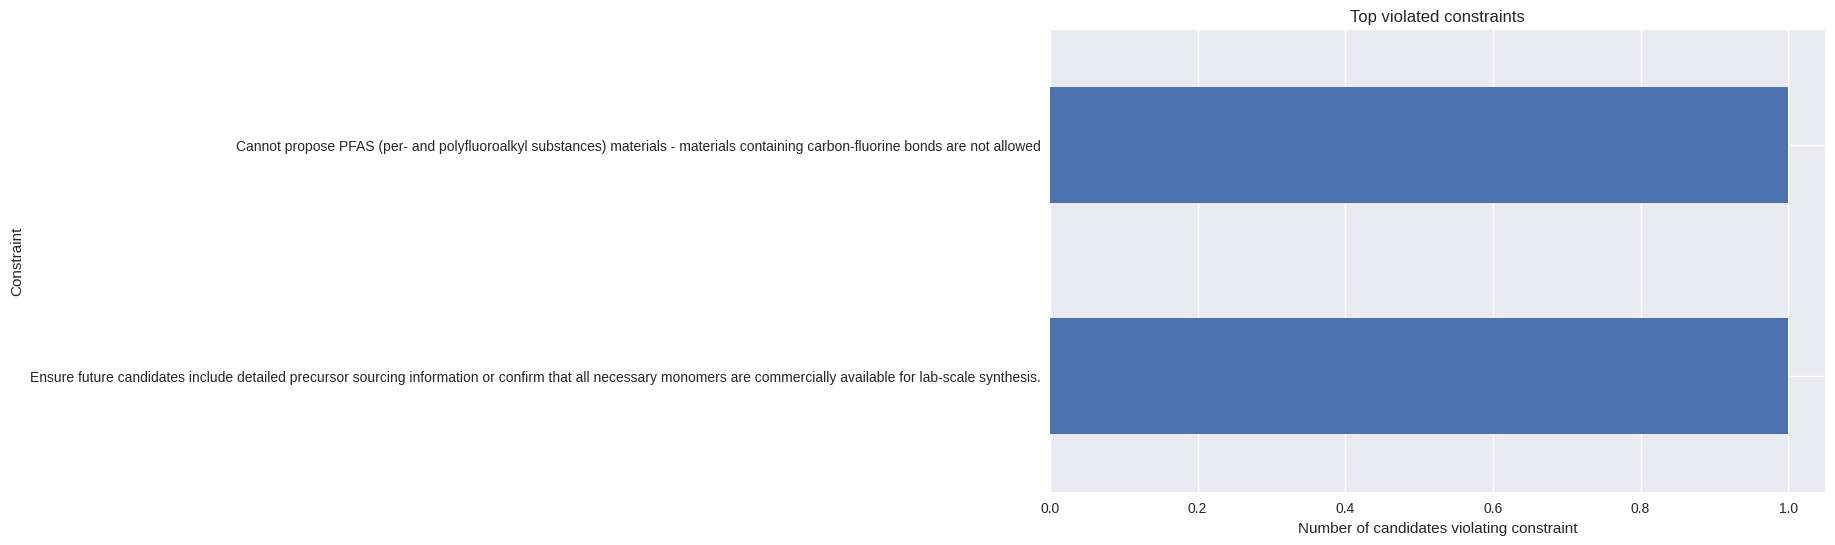

In [11]:
rejected = evaluation.get("candidate_selection", {}).get("rejected_candidates", []) or []

if not rejected:
    display(Markdown("_No rejected candidates recorded._"))
else:
    rows = []
    all_violated = []
    for r in rejected:
        cand = r.get("candidate", "<unknown>")
        reason = (r.get("reasoning") or "").strip()
        source = r.get("source") or "unspecified"
        violated = r.get("constraints_violated", []) or []
        count = len(violated)

        rows.append(
            {
                "candidate": cand,
                "source": source,
                "num_constraints_violated": count,
                "reasoning": reason,
            }
        )
        for c in violated:
            all_violated.append({"candidate": cand, "source": source, "constraint": c})

    rej_df = pd.DataFrame(rows)
    display(Markdown("### Rejected candidates (summary)"))
    display(rej_df)

    if all_violated:
        viol_df = pd.DataFrame(all_violated)

        by_constraint = viol_df.groupby("constraint").size().sort_values(ascending=False)
        display(Markdown("### Violated constraints (frequency)"))
        display(by_constraint.to_frame(name="count"))

        plt.figure(figsize=(10, 6))
        by_constraint.head(15).plot(kind="barh")
        plt.gca().invert_yaxis()
        plt.xlabel("Number of candidates violating constraint")
        plt.ylabel("Constraint")
        plt.title("Top violated constraints")
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("_Rejected candidates did not record specific violated constraints._"))


## Manufacturing process and blocking constraints

Show the manufacturing process status and any blocking constraints reported by System 3.


In [12]:
mfg = evaluation.get("manufacturing_process", {}) or {}

display(Markdown("### Manufacturing process status"))
status = mfg.get("status", "N/A")
display(Markdown(f"- **Status:** `{status}`"))

process_recipe = mfg.get("process_recipe")
if process_recipe:
    display(Markdown("#### Process recipe (raw JSON)"))
    display(process_recipe)
else:
    display(Markdown("_No process recipe was produced in this evaluation._"))

blocking = mfg.get("blocking_constraints", []) or []
if blocking:
    rows = []
    for b in blocking:
        rows.append(
            {
                "type": b.get("type", ""),
                "severity": b.get("severity", ""),
                "description": b.get("description", ""),
                "suggested_mitigation": b.get("suggested_mitigation", ""),
            }
        )
    block_df = pd.DataFrame(rows)
    display(Markdown("### Blocking constraints"))
    display(block_df)
else:
    display(Markdown("_No blocking manufacturing constraints found._"))


### Manufacturing process status

- **Status:** `manufacturable`

#### Process recipe (raw JSON)

[{'step_index': 1,
  'description': 'Dry the PEEK pellets and MoS₂ powder to remove moisture.',
  'conditions': 'temperature: 150–160\u202f°C; time: 2–4\u202fh; atmosphere: ambient air',
  'equipment_class': 'Drying oven or convection oven',
  'inputs': ['KEBAPEAK PEEK XS1300 pellets',
   'MoS₂ powder (5\u202fwt% of total weight)']},
 {'step_index': 2,
  'description': 'Pre‑mix the dried polymer and filler in a high‑shear mixer or twin‑screw extruder to achieve uniform dispersion.',
  'conditions': "barrel_temperature_profile: [{'zone': 1, 'temp': '350\\u202f°C'}, {'zone': 2, 'temp': '360\\u202f°C'}, {'zone': 3, 'temp': '370\\u202f°C'}]; screw_speed: 30–40\u202frpm; feed_rate: 0.5–1.0\u202fkg/h",
  'equipment_class': 'Twin‑screw extruder (lab scale)',
  'inputs': ['Dried KEBAPEAK PEEK XS1300 pellets',
   'MoS₂ powder (5\u202fwt%)']},
 {'step_index': 3,
  'description': 'Melt‑compound the mixture to produce strands, pelletise and cool.',
  'conditions': 'strand_temperature: 380–390\u202

_No blocking manufacturing constraints found._